In [17]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

import warnings
warnings.filterwarnings("ignore")

LABEL2IDX = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
IDX2LABEL = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
option_cols = ['A', 'B', 'C', 'D', 'E']

**Data loading**

In [19]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (2000, 8)
Test shape: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**EDA Part**

**EDA - answer distribution**

If one letter was much more common, the model could cheat by always guessing that letter.

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


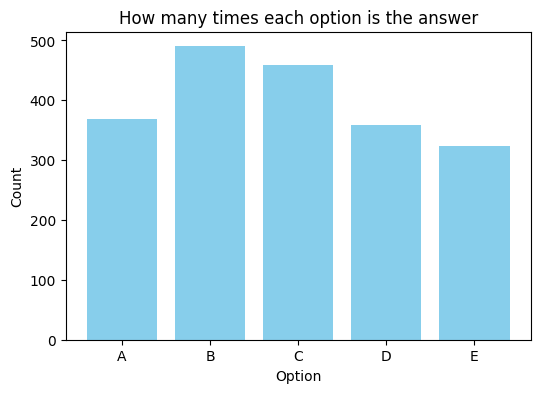

Random guessing = 20 %


In [20]:
counts = train['answer'].value_counts().reindex(option_cols, fill_value=0)
print(counts)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.title("How many times each option is the answer")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

print("Random guessing = 20 %")

**EDA - word overlap between prompt and options**

TF-IDF is basically measuring shared words, so I check how good it is to simply pick the
option that shares the most words with the question. This is the baseline my model must beat.

In [21]:
def get_overlap(prompt, option):
    p = set(str(prompt).lower().split())
    o = set(str(option).lower().split())
    if len(o) == 0:
        return 0
    return len(p & o) / len(o)

for col in option_cols:
    train['overlap_' + col] = [get_overlap(p, o) for p, o in zip(train['prompt'], train[col])]
    train['len_' + col] = train[col].apply(lambda x: len(str(x).split()))

best_ov = train[['overlap_' + c for c in option_cols]].idxmax(axis=1).str.replace('overlap_', '')
best_len = train[['len_' + c for c in option_cols]].idxmax(axis=1).str.replace('len_', '')

print("Accuracy of picking the most overlapping option:", round((best_ov == train['answer']).mean() * 100, 2), "%")
print("Accuracy of picking the longest option        :", round((best_len == train['answer']).mean() * 100, 2), "%")
print("Random guessing                               : 20.0 %")

Accuracy of picking the most overlapping option: 9.25 %
Accuracy of picking the longest option        : 34.95 %
Random guessing                               : 20.0 %


**Cleaning**

In [22]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

for df in [train, test]:
    for col in ['prompt'] + option_cols:
        df[col] = df[col].fillna("").apply(clean_text)

print(train.loc[0, 'prompt'][:200])

pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.


**One question becomes five rows**

The letters A to E mean nothing by themselves, so I do not classify the letter. I turn
every question into five (prompt, option) pairs and train a binary model that answers one
question: is this option the correct one? Later I compare the five scores and pick the best.

In [23]:
def flatten(df, is_train=True):
    rows = []
    for i in range(len(df)):
        row = df.iloc[i]
        prompt = str(row['prompt'])
        prompt_words = set(prompt.split())
        lens = [len(str(row[c]).split()) for c in option_cols]
        mean_len = np.mean(lens) + 1e-6
        ans = LABEL2IDX[row['answer']] if is_train else -1

        for j, c in enumerate(option_cols):
            opt = str(row[c])
            opt_words = set(opt.split())
            others = " ".join(str(row[k]) for k in option_cols if k != c)
            rows.append({
                'qid': i,
                'prompt': prompt,
                'option': opt,
                'others': others,                                    # the other 4 options
                'opt_len': lens[j],
                'len_ratio': lens[j] / mean_len,                     # longest option trick
                'overlap': len(prompt_words & opt_words) / (len(opt_words) + 1e-6),
                'y': 1 if j == ans else 0,
            })
    return pd.DataFrame(rows)

train_pairs = flatten(train)
test_pairs = flatten(test, is_train=False)
print("Train pairs:", train_pairs.shape, " Test pairs:", test_pairs.shape)
train_pairs.head()

Train pairs: (10000, 8)  Test pairs: (2500, 8)


,qid,prompt,option,others,opt_len,len_ratio,overlap,y
0,0,pick the best possible answer: what is martin ...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,51,1.328125,0.153846,0
1,0,pick the best possible answer: what is martin ...,martin heidegger believes that humans do not e...,martin heidegger believes that humans exist wi...,41,1.067708,0.147059,1
2,0,pick the best possible answer: what is martin ...,martin heidegger does not believe in the exist...,martin heidegger believes that humans exist wi...,38,0.989583,0.275862,0
3,0,pick the best possible answer: what is martin ...,martin heidegger believes that the relationshi...,martin heidegger believes that humans exist wi...,31,0.807292,0.320000,0
4,0,pick the best possible answer: what is martin ...,martin heidegger believes that time is an illu...,martin heidegger believes that humans exist wi...,31,0.807292,0.178571,0


**TF-IDF features**

In [24]:
all_texts = []
for df in [train, test]:
    for col in ['prompt'] + option_cols:
        all_texts = all_texts + df[col].tolist()
print("Documents used to fit TF-IDF:", len(all_texts))

word_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, token_pattern=r'\w+')
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True)
word_vec.fit(all_texts)
char_vec.fit(all_texts)
print("Word vocab:", len(word_vec.vocabulary_), " Char vocab:", len(char_vec.vocabulary_))

Documents used to fit TF-IDF: 15000
Word vocab: 12835  Char vocab: 23890


In [25]:
scaler = StandardScaler()

def make_features(pairs, fit_scaler=False):
    Pw, Ow = word_vec.transform(pairs['prompt']), word_vec.transform(pairs['option'])
    Pc, Oc = char_vec.transform(pairs['prompt']), char_vec.transform(pairs['option'])
    Xw, Xc = Pw.multiply(Ow), Pc.multiply(Oc)

    Nw = word_vec.transform(pairs['others'])
    sim_others = np.asarray(Nw.multiply(Ow).sum(axis=1)).ravel()
    sim_prompt = np.asarray(Xw.sum(axis=1)).ravel()

    dense = np.column_stack([
        pairs['opt_len'].to_numpy(dtype=float),
        pairs['len_ratio'].to_numpy(dtype=float),
        pairs['overlap'].to_numpy(dtype=float),
        sim_prompt,
        sim_others,
    ])
    dense = scaler.fit_transform(dense) if fit_scaler else scaler.transform(dense)

    return hstack([Ow, Xw, Oc, Xc, csr_matrix(dense)]).tocsr()

X = make_features(train_pairs, fit_scaler=True)
X_test = make_features(test_pairs)
y = train_pairs['y'].to_numpy()
y_q = train['answer'].map(LABEL2IDX).to_numpy()

print("Train features:", X.shape)
print("Test features :", X_test.shape)

Train features: (10000, 73455)
Test features : (2500, 73455)


**Compare the 5 options and the MAP@3 metric**

In [26]:
def group_scores(scores, n_questions):
    s = scores.reshape(n_questions, 5)
    s = s - s.max(axis=1, keepdims=True)
    e = np.exp(s)
    return e / e.sum(axis=1, keepdims=True)

def map_at_3(probs, targets):
    top3 = np.argsort(-probs, axis=1)[:, :3]
    score = 0.0
    for i in range(len(targets)):
        for rank in range(3):
            if top3[i][rank] == targets[i]:
                score = score + 1.0 / (rank + 1)
                break
    return score / len(targets)

def rows_of(qidx):
    # question indices -> the 5 flat row indices of each question
    return np.concatenate([np.arange(q * 5, q * 5 + 5) for q in qidx])

**Choose C on a validation split**

In [27]:
q_idx = np.arange(len(train))
tr_q, va_q = train_test_split(q_idx, test_size=0.15, random_state=42, stratify=y_q)

X_tr, y_tr = X[rows_of(tr_q)], y[rows_of(tr_q)]
X_va = X[rows_of(va_q)]

results = []
for C in [1, 3, 10, 30]:
    m = LogisticRegression(C=C, class_weight='balanced', max_iter=3000)
    m.fit(X_tr, y_tr)

    probs = group_scores(m.decision_function(X_va), len(va_q))
    pred = probs.argmax(axis=1)
    results.append({
        "C": C,
        "val_acc": accuracy_score(y_q[va_q], pred),
        "val_f1": f1_score(y_q[va_q], pred, average='macro'),
        "val_map3": map_at_3(probs, y_q[va_q]),
    })
    print("C =", C, "-> acc:", round(results[-1]['val_acc'], 4), " map3:", round(results[-1]['val_map3'], 4))

results = pd.DataFrame(results).sort_values("val_map3", ascending=False)
BEST_C = float(results.iloc[0]['C'])
print()
print(results)
print()
print("Best C:", BEST_C)

C = 1 -> acc: 0.9833  map3: 0.9917
C = 3 -> acc: 0.9933  map3: 0.9983
C = 10 -> acc: 0.9967  map3: 1.0
C = 30 -> acc: 0.9967  map3: 1.0

    C   val_acc    val_f1  val_map3
3  30  0.996667  0.996692  1.000000
2  10  0.996667  0.996692  1.000000
1   3  0.993333  0.993212  0.998333
0   1  0.983333  0.983362  0.991667

Best C: 30.0


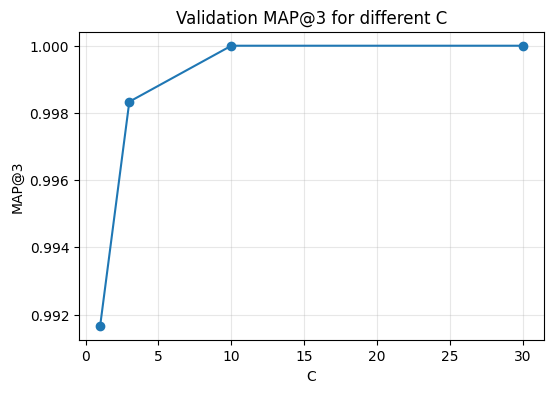

In [28]:
r = results.sort_values("C")
plt.figure(figsize=(6, 4))
plt.plot(r["C"], r["val_map3"], marker='o')
plt.title("Validation MAP@3 for different C")
plt.xlabel("C")
plt.ylabel("MAP@3")
plt.grid(True, alpha=0.3)
plt.show()

**5-fold bagging on the full data**

In [29]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros((len(train), 5))
test_probs = np.zeros((len(test), 5))

for fold, (tr_q, va_q) in enumerate(kf.split(q_idx, y_q)):
    m = LogisticRegression(C=BEST_C, class_weight='balanced', max_iter=3000)
    m.fit(X[rows_of(tr_q)], y[rows_of(tr_q)])

    oof[va_q] = group_scores(m.decision_function(X[rows_of(va_q)]), len(va_q))
    test_probs = test_probs + group_scores(m.decision_function(X_test), len(test)) / 5

    print("Fold", fold + 1, "map3:", round(map_at_3(oof[va_q], y_q[va_q]), 4))

print()
print("Out-of-fold accuracy:", round(accuracy_score(y_q, oof.argmax(axis=1)), 4))
print("Out-of-fold F1      :", round(f1_score(y_q, oof.argmax(axis=1), average='macro'), 4))
print("Out-of-fold MAP@3   :", round(map_at_3(oof, y_q), 4))

Fold 1 map3: 1.0
Fold 2 map3: 1.0
Fold 3 map3: 0.9988
Fold 4 map3: 1.0
Fold 5 map3: 0.9983

Out-of-fold accuracy: 0.9945
Out-of-fold F1      : 0.9944
Out-of-fold MAP@3   : 0.9994


**Prediction and submission**

In [30]:
top3 = np.argsort(-test_probs, axis=1)[:, :3]
predictions = [IDX2LABEL[r[0]] + " " + IDX2LABEL[r[1]] + " " + IDX2LABEL[r[2]] for r in top3]

submission = pd.DataFrame({'ID': test['id'], 'Prediction': predictions})
submission.to_csv("submission.csv", index=False)

print("submission.csv created, shape:", submission.shape)
submission.head()

submission.csv created, shape: (500, 2)


,ID,Prediction
0,1,A E D
1,2,B E C
2,3,B E D
3,4,E C D
4,5,C A D


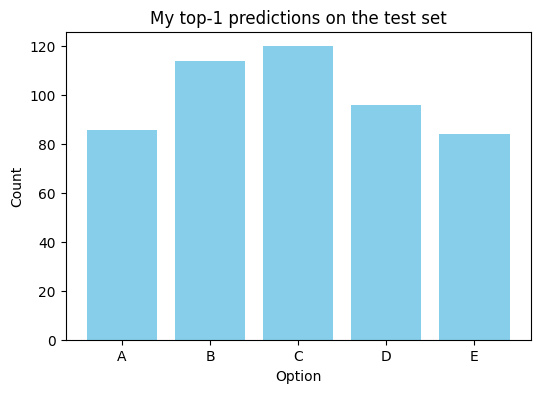

A     86
B    114
C    120
D     96
E     84
Name: count, dtype: int64


In [31]:
first = pd.Series([p.split()[0] for p in predictions]).value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(first.index, first.values, color='skyblue')
plt.title("My top-1 predictions on the test set")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

print(first)